In [74]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import sys
import os
import matplotlib.ticker as ticker

### Filepaths

In [75]:
### Changing to parent directory
current_file_path = Path("").resolve()
grandparent_dir = current_file_path.parent.parent
# Append this directory to the system path
sys.path.append(str(grandparent_dir))

In [76]:
filepath = os.path.join(grandparent_dir,"Processed Data/preprocessed_data_final.csv")

### Imported Dataframes

In [77]:
def create_dataframe(filepath, rank, file_num, val_prefix):
    
    '''
    Creates a table of the value for each harmonic integer (1-10) 
    for a given rank and file number (or run number).
    
    Args: 
        filepath (string): filepath to processed data .csv
        file_num (int): file (or run) number
        val_prefix (string): column prefix name to desired value (e.g. "IHr")
    
    Return:
        df_res (pd.DataFrame): resulting dataframe
    
    '''
    
    #Read File
    df = pd.read_csv(filepath)
    df = df[(df["Rank"] == rank) & df["File Number"] == file_num]
    
    #Generate Names of Harmonic Data Columns
    nums = [x for x in range(1,11)]
    cols = [f"{val_prefix}{num}" for num in nums]
    
    #Extract Data from Specific Named Columns
    freq = float(df["Freq"].iloc[0])
    df_res = df[["Modulation (RMS)"]+cols]
    df_res = df_res.set_index("Modulation (RMS)").T
    
    #Create Harmonic Number/Frequency Labeling
    df_res = df_res.reset_index().rename(columns={"index": "Harmonic j"})
    df_res["Harmonic j"] = nums
    df_res.insert(1, "Frequency (Hz)", [x*freq for x in nums])
    return df_res
    

In [78]:
df_Vreal = create_dataframe(filepath, 6, 1, "VHr")
df_Vimag = create_dataframe(filepath, 6, 1, "VHi")
df_Ireal = create_dataframe(filepath, 6, 1, "IHr")
df_Iimag = create_dataframe(filepath, 6, 1, "IHi")

In [79]:
df_Iimag

Modulation (RMS),Harmonic j,Frequency (Hz),1mV,5mV,10mV,20mV,50mV,100mV
0,1,0.300481,8.958093e-07,4.455925e-06,8.729169e-06,1.662424e-05,3.207552e-05,4.164019e-05
1,2,0.600962,-8.079738e-10,-2.082125e-08,-7.105728e-08,-2.331658e-07,-6.523790e-07,-5.092441e-07
2,3,0.901442,3.618164e-10,-1.050248e-08,-8.318156e-08,-6.060602e-07,-5.332940e-06,-1.377129e-05
3,4,1.201923,-1.323197e-10,1.466366e-09,4.337077e-09,1.974882e-08,2.255380e-07,5.405711e-07
4,5,1.502404,-8.713607e-10,-7.568260e-10,5.738896e-10,1.989950e-08,9.074821e-07,5.552749e-06
5,6,1.802885,-5.272011e-10,-3.080183e-10,-2.265182e-09,-4.084670e-09,-5.605983e-08,-3.173055e-07
6,7,2.103366,1.881023e-11,4.738740e-11,5.283169e-10,-3.876912e-10,-1.395221e-07,-2.125465e-06
7,8,2.403846,3.779482e-10,6.676135e-10,2.710644e-09,2.989216e-09,1.437565e-08,1.560568e-07
8,9,2.704327,-5.855394e-10,-2.281522e-10,-2.508249e-11,-3.994540e-10,1.979235e-08,7.761877e-07
9,10,3.004808,-1.296331e-11,-6.077249e-10,-9.171433e-10,-1.432548e-09,-5.802976e-09,-7.078626e-08


In [80]:
df_Ireal

Modulation (RMS),Harmonic j,Frequency (Hz),1mV,5mV,10mV,20mV,50mV,100mV
0,1,0.300481,8.991344e-07,4.475380e-06,8.822680e-06,1.674612e-05,3.157496e-05,3.896409e-05
1,2,0.600962,5.569373e-11,-1.907635e-08,-7.348918e-08,-2.583914e-07,-7.633524e-07,-7.527848e-07
2,3,0.901442,9.451560e-10,-9.478082e-09,-9.111328e-08,-6.844668e-07,-5.921104e-06,-1.488540e-05
3,4,1.201923,-4.107165e-10,-5.489390e-10,5.738410e-10,1.777381e-08,2.560023e-07,5.869554e-07
4,5,1.502404,-1.186874e-09,-2.248029e-09,-2.027699e-09,2.106762e-08,1.067574e-06,6.202561e-06
5,6,1.802885,-3.467756e-10,7.153264e-10,2.975397e-10,-5.787066e-10,-6.399536e-08,-3.561545e-07
6,7,2.103366,3.859746e-10,1.069199e-09,2.526314e-09,2.315232e-09,-1.740575e-07,-2.472037e-06
7,8,2.403846,2.556695e-10,-3.125230e-10,7.458783e-10,1.820880e-10,1.353783e-08,1.823170e-07
8,9,2.704327,-1.094227e-09,-9.216352e-10,-2.042163e-09,-2.682011e-09,2.376731e-08,9.468776e-07
9,10,3.004808,-1.022601e-11,4.926822e-11,8.526377e-10,5.340902e-10,-2.468587e-09,-8.495493e-08


____

### Functions

In [81]:
def scale_series_tail(series, factor, type, conv_flag):
    '''
    Scales the tail end of a series (after index 0) by a given factor
    
    Args: 
        series (pd.Series): input current or voltage series
        factor (int): number that tail end of series will be multiplied by
        type (string): "V" for voltage series and "A" for current series
        conv_flag (boolean): True will convert series to mV or mA, depending on type
    
    Return:
        scaled (pd.Series): modified input series with multiplier applied
    
    '''
    
    conversion = 1
    if conv_flag == True:
        if type == "V":
            conversion = 10**3
        if type == "A":
            conversion = 10**6
        
    if series.empty:
        return series.copy()
    scaled = series.copy() * conversion
    scaled.iloc[1:] = scaled.iloc[1:] * factor
    return scaled

In [82]:
def scale_series_2_ranges(series, start,stop,start2,stop2, factor,factor2, type, conv_flag):
    '''
    Scales two specific ranges of a series by each a given factor
    
    Args: 
        series (pd.Series): input current or voltage series
        start (int): index of series to start first section
        stop (int): index of series to stop first section
        start2 (int): index of series to start second section
        stop2 (int): index of series to stop second section
        factor (int): number that section 1 of series will be multiplied by
        factor2 (int): number that section 2 of series will be multiplied by
        type (string): "V" for voltage series and "A" for current series
        conv_flag (boolean): True will convert series to mV or mA, depending on type
    
    Return:
        scaled (pd.Series): modified input series with the two multipliers applied
    '''
    
    conversion = 1
    if conv_flag == True:
        if type == "V":
            conversion = 10**3
        if type == "A":
            conversion = 10**6
        
    if series.empty:
        return series.copy()
    scaled = series.copy() * conversion
    scaled.iloc[start:stop+1] = scaled.iloc[start:stop+1] * factor
    scaled.iloc[start2:stop2+1] = scaled.iloc[start2:stop2+1] * factor2
    return scaled

In [83]:
def add_bracket(ax, x_start_data, x_end_data, y_top_pct, y_height_pct):
    """
    Draws an upturned or downturned bracket onto a given plot (depending on sign of y_height_pct)
    
    Args:
        ax (matplotlib.axes._axes.Axes): axes of plot to put bracket on
        x_start_data (float): x-value on plot axis to draw left endpoint of bracket
        x_end_data (flaot): x_value on plot axis to draw right endpoint of bracket
        y_top_pct (float): percentage of plot y-axis from bottom edge to draw top of bracket to
        y_height_pct (float): positive (downturned) or negative (upturned) height 
        for bracket legs based on percentage of y-axis total height
    
    Return:
        None
    """
    # Get axis limits for y to compute actual y-coordinates
    y_min, y_max = ax.get_ylim()
    y_top = y_min + y_top_pct * (y_max - y_min)
    y_bottom = y_top - y_height_pct * (y_max - y_min)

    # Draw horizontal line
    ax.plot([x_start_data, x_end_data], [y_top, y_top], color='black', linewidth=1)

    # Draw vertical ends
    ax.plot([x_start_data, x_start_data], [y_top, y_bottom], color='black', linewidth=1)
    ax.plot([x_end_data, x_end_data], [y_top, y_bottom], color='black', linewidth=1)

____

# 1. Voltage Shifted

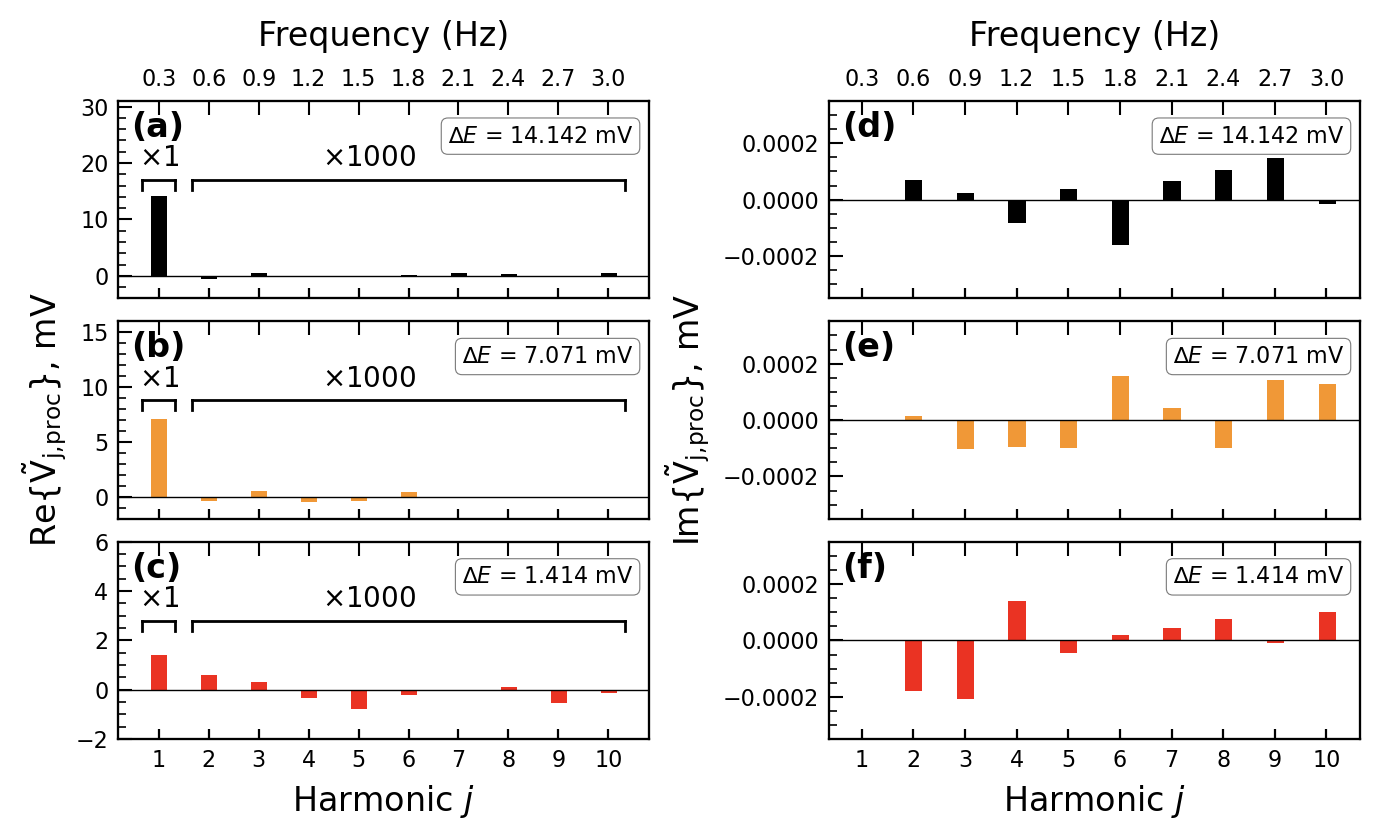

In [84]:
#Create Figure
fig, axs = plt.subplots(3, 2, sharex='col', figsize=(7, 4.3),dpi=200)
for ax in axs.flat:
    for location in ['left', 'right', 'top', 'bottom']:
        ax.spines[location].set_linewidth(0.75)

#Plot Variables
fontsize=12
label_fontsize = 12
legend_fontsize = 8
axis_fontsize = 8
mult_fontsize = 10
bar_width = 0.1
frequencies = df_Vreal['Frequency (Hz)']
colors = [(234, 51, 35), (240, 152, 55), (0, 0, 0)]
colors = [tuple(c / 255 for c in color) for color in colors]
labels = [rf"$∆E$ = {round(10*np.sqrt(2),3)} mV", rf"$∆E$ = {round(5*np.sqrt(2),3)} mV", rf"$∆E$ = {round(1*np.sqrt(2),3)} mV"]
cols = ["10mV", "5mV", "1mV"]
subplot_labels = ['(a)', '(d)', '(b)', '(e)', '(c)', '(f)']
y_lims_min = [-4, -2, -2]
y_lims_max = [31, 16, 6]
gray_rgb = (122/255, 122/255, 122/255)
mult_reals = [1000,1000,1000]
mult_imags = [1000,1000,1000]
y_major_real = [10, 5, 2]
y_minor_real = [2, 1, 0.5]
y_major_imag = [0.0002, 0.0002, 0.0002]
y_minor_imag = [0.00005, 0.00005, 0.00005]

count = 0
for i in range(3):
    # LEFT: Real Voltage
    axs[i, 0].bar(frequencies, scale_series_tail(df_Vreal[cols[i]], mult_reals[i], "V", True),
                  width=bar_width, color=colors[2 - i])
    if i == 1:
        axs[i, 0].set_ylabel(r'Re{$\tilde{\mathrm{V}}_{\mathrm{j,\!{proc}}}$}, mV', fontsize=fontsize)
    axs[i, 0].set_ylim(y_lims_min[i], y_lims_max[i])


    # RIGHT: Imaginary Voltage
    axs[i, 1].bar(frequencies, df_Vimag[cols[i]] * 1e3,  # mV
                  width=bar_width, color=colors[2 - i])
    if i == 1:
        axs[i, 1].set_ylabel(r'Im{$\tilde{\mathrm{V}}_{\mathrm{j,\!{proc}}}$}, mV', fontsize=fontsize)
    axs[i, 1].set_ylim(-0.00035, 0.00035)  # in mV

    #Format Axes / Tick Marks / Add Brackets
    for j in [0, 1]:
        ax = axs[i, j]
        if j == 0:
            minor = y_minor_real
            major = y_major_real
        else:
            minor = y_minor_imag
            major = y_major_imag
        ax.minorticks_on()
        ax.yaxis.set_major_locator(ticker.MultipleLocator(major[i]))
        ax.yaxis.set_minor_locator(ticker.MultipleLocator(minor[i]))
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
        ax.tick_params(axis='x', which='minor', bottom=False, top=False)
        ax.tick_params(axis='y', which='major', length=5, width=0.75)
        ax.tick_params(axis='y', which='minor', length=3, width=0.6)
        ax.tick_params(which='both', direction='in', labelsize=axis_fontsize)
        ax.text(0.025, 0.95, subplot_labels[count], transform=ax.transAxes,
            fontsize=label_fontsize, fontweight='bold', va='top', ha='left')

        # Create Custom Legend Textbox
        ax.text(0.97, 0.88, labels[i],
                transform=ax.transAxes,
                fontsize=legend_fontsize,
                verticalalignment='top',
                horizontalalignment='right',
                bbox=dict(boxstyle='round',
                          facecolor='white',
                          edgecolor=gray_rgb,
                          linewidth=0.4))

        # Brackets under x-axis (only on Real side)
        if j == 0:
            overhang = 0.05
            x1_start, x1_end = 0.15 + overhang, 0.45 - overhang
            x2_start, x2_end = 0.45 + overhang, 3.15 - overhang
            x1_mid = (x1_start + x1_end) / 2
            x2_mid = (x2_start + x2_end) / 2
            add_bracket(ax, x1_start, x1_end, 0.6, 0.05)
            add_bracket(ax, x2_start, x2_end, 0.6, 0.05)
            ax.text(x1_mid, 0.78, r'$\times 1$', transform=ax.get_xaxis_transform(),
                    fontsize=mult_fontsize, verticalalignment='top', horizontalalignment='center')
            ax.text(x2_mid*0.87, 0.78, rf'$\times {mult_reals[i]}$', transform=ax.get_xaxis_transform(),
                    fontsize=mult_fontsize, verticalalignment='top', horizontalalignment='center')

        count += 1

# X-axis ticks (shared between bottom harmonic axis and top frequency axis)
xticks_pos = [0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1, 2.4, 2.7, 3.0]
harmonic_nums = range(1, 11)

# BOTTOM row: harmonic numbers
for j in [0, 1]:
    axs[2, j].set_xlabel('Harmonic $j$', fontsize=fontsize)
    axs[2, j].set_xticks(xticks_pos)
    axs[2, j].set_xticklabels(harmonic_nums)

# TOP/MIDDLE/BOTTOM rows: twin x-axis with frequency tick positions
for i in range(3):
    for j in [0, 1]:
        ax = axs[i, j]
        if j == 0:
            minor = y_minor_real
            major = y_major_real
        else:
            minor = y_minor_imag
            major = y_major_imag
        ax.xaxis.set_minor_locator(ticker.NullLocator())
        ax.yaxis.set_minor_locator(ticker.MultipleLocator(minor[i]))
        ax_top = ax.twiny()
        ax_top.set_xlim(ax.get_xlim())
        ax_top.set_xticks(xticks_pos)
        ax_top.xaxis.set_minor_locator(ticker.NullLocator())  # no minor on top axis either
        ax_top.tick_params(axis='x', which='major', length=5, width=0.75,
                           direction='in')
        ax_top.tick_params(which='both', labelsize=axis_fontsize)
        if i == 0:
            ax_top.set_xticklabels(xticks_pos)
            ax_top.set_xlabel('Frequency (Hz)', fontsize=fontsize, labelpad=8)
        else:
            ax_top.set_xticklabels([])

#Show/Save Figure
plt.tight_layout(h_pad=0.5, w_pad=0.5)
plt.savefig("S2_Processed_Voltage_Signal_Analysis.pdf", bbox_inches='tight', pad_inches=0.01)
plt.show()


# 2. Current Shifted

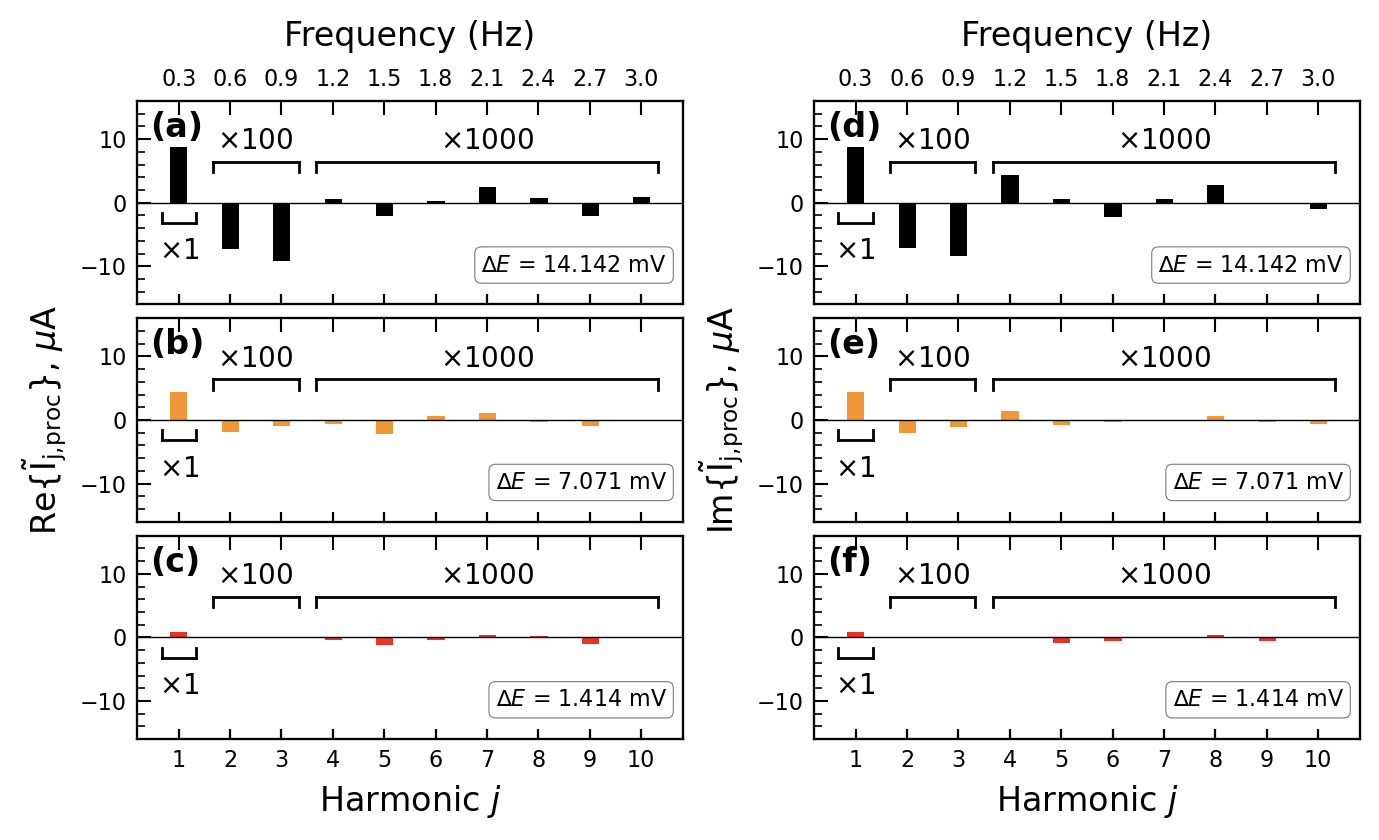

In [85]:
#Create Figure
fig, axs = plt.subplots(3, 2, sharex='col', figsize=(7, 4.3),dpi=200) #11,6
for ax in axs.flat:
    for location in ['left', 'right', 'top', 'bottom']:
        ax.spines[location].set_linewidth(0.75)

#Plot Variables
fontsize=12
label_fontsize = 12
legend_fontsize = 8
axis_fontsize = 8
mult_fontsize = 10
bar_width = 0.1
frequencies = df_Vreal['Frequency (Hz)']
colors = [(234, 51, 35), (240, 152, 55), (0, 0, 0)]
colors = [tuple(c / 255 for c in color) for color in colors]
labels = [rf"$∆E$ = {round(10*np.sqrt(2),3)} mV", rf"$∆E$ = {round(5*np.sqrt(2),3)} mV", rf"$∆E$ = {round(1*np.sqrt(2),3)} mV"]
cols = ["10mV","5mV","1mV"]
subplot_labels = ['(a)', '(d)', '(b)', '(e)', '(c)', '(f)']
mult = 100
mult2 = 1000
gray_rgb = (122 / 255, 122 / 255, 122 / 255)
count = 0
y_major = [10, 10, 10]
y_minor = [2, 2, 2]

for i in range(3):
    # LEFT: Real Current
    axs[i, 0].bar(frequencies, scale_series_2_ranges(df_Ireal[cols[i]], 1, 2, 3,
                len(df_Ireal[cols[i]]) - 1, mult, mult2, "A", True),
                width=bar_width, color=colors[2 - i])
    if i ==1:
        axs[i, 0].set_ylabel(r'Re{$\tilde{\mathrm{I}}_{\mathrm{j,\!{proc}}}$}, $\mu$A', fontsize=fontsize)
    axs[i, 0].set_ylim(-16, 16)

    # RIGHT: Imaginary Current
    axs[i, 1].bar(frequencies, scale_series_2_ranges(df_Iimag[cols[i]], 1, 2, 3,
                len(df_Iimag[cols[i]]) - 1, mult, mult2, "A", True),
                width=bar_width, color=colors[2 - i])
    axs[i, 1].set_ylim(-16, 16)
    if i ==1:
        axs[i, 1].set_ylabel(r'Im{$\tilde{\mathrm{I}}_{\mathrm{j,\!{proc}}}$}, $\mu$A', fontsize=fontsize)

    #Format Axes / Tick Marks / Add Brackets 
    for j in [0, 1]:
        ax = axs[i, j]
        ax.minorticks_on()
        ax.yaxis.set_major_locator(ticker.MultipleLocator(y_major[i]))
        ax.yaxis.set_minor_locator(ticker.MultipleLocator(y_minor[i]))
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
        ax.tick_params(axis='x', which='minor', bottom=False, top=False)
        ax.tick_params(axis='y', which='major', length = 5,width = 0.75)
        ax.tick_params(axis='y', which='minor', length = 3, width = 0.6)
        ax.tick_params(which='both', direction='in', labelsize=axis_fontsize)
        ax.text(0.025, 0.95, subplot_labels[count], transform=ax.transAxes,
                fontsize=label_fontsize, fontweight='bold', va='top', ha='left')

        # Custom Legend Textbox
        ax.text(0.97, 0.25, labels[i],
                transform=ax.transAxes,
                fontsize=legend_fontsize,
                verticalalignment='top',
                horizontalalignment='right',
                bbox=dict(boxstyle='round',
                          facecolor='white',
                          edgecolor=gray_rgb,
                          linewidth=0.4))

        # Brackets and scaling
        overhang = 0.05
        x1_start, x1_end = 0.15 + overhang, 0.45 - overhang
        x2_start, x2_end = 0.45 + overhang, 1.05 - overhang
        x3_start, x3_end = 1.05 + overhang, 3.15 - overhang
        x1_mid = (x1_start + x1_end) / 2
        x2_mid = (x2_start + x2_end) / 2
        x3_mid = (x3_start + x3_end) / 2
        add_bracket(ax, x1_start, x1_end, 0.4, -0.05)
        add_bracket(ax, x2_start, x2_end, 0.7, 0.05)
        add_bracket(ax, x3_start, x3_end, 0.7, 0.05)
        ax.text(x1_mid, 0.33, r'$\times 1$', transform=ax.get_xaxis_transform(),
                fontsize=mult_fontsize, verticalalignment='top', horizontalalignment='center')
        ax.text(x2_mid, 0.87, rf'$\times {mult}$', transform=ax.get_xaxis_transform(),
                fontsize=mult_fontsize, verticalalignment='top', horizontalalignment='center')
        ax.text(x3_mid, 0.87, rf'$\times {mult2}$', transform=ax.get_xaxis_transform(),
                fontsize=mult_fontsize, verticalalignment='top', horizontalalignment='center')
        
        count += 1

# X-axis ticks (shared between bottom harmonic axis and top frequency axis)
xticks_pos = [0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1, 2.4, 2.7, 3.0]
harmonic_nums = range(1, 11)

# BOTTOM row: harmonic numbers
for j in [0, 1]:
    axs[2, j].set_xlabel('Harmonic $j$', fontsize=fontsize)
    axs[2, j].set_xticks(xticks_pos)
    axs[2, j].set_xticklabels(harmonic_nums)

# TOP/MIDDLE/BOTTOM rows: twin x-axis with frequency tick positions
for i in range(3):
    for j in [0, 1]:
        ax = axs[i, j]
        ax.xaxis.set_minor_locator(ticker.NullLocator())
        ax.yaxis.set_minor_locator(ticker.MultipleLocator(y_minor[i]))
        ax_top = ax.twiny()
        ax_top.set_xlim(ax.get_xlim())
        ax_top.set_xticks(xticks_pos)
        ax_top.xaxis.set_minor_locator(ticker.NullLocator())  # no minor on top axis either
        ax_top.tick_params(axis='x', which='major', length=5, width=0.75,
                           direction='in')
        ax_top.tick_params(which='both', labelsize=axis_fontsize)
        if i == 0:
            ax_top.set_xticklabels(xticks_pos)
            ax_top.set_xlabel('Frequency (Hz)', fontsize=fontsize, labelpad=8)
        else:
            ax_top.set_xticklabels([])


#Show/Save Figure
plt.tight_layout(h_pad = 0.5,w_pad=0.5)
plt.savefig("Figure2_Processed_Current_Signal_Analysis.pdf", bbox_inches='tight', pad_inches=0.01)
plt.show()


# 3. TOC Graphic

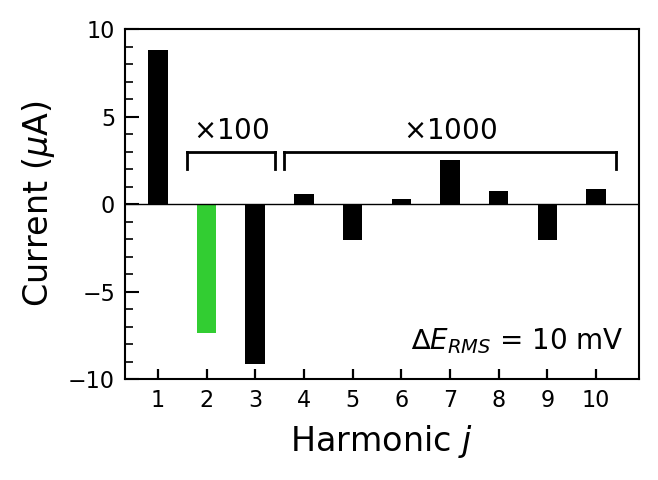

In [86]:
#Create Figure
fig, ax = plt.subplots(1,1,figsize=(3.5, 2.5),dpi=200) #11,6

for location in ['left', 'right', 'top', 'bottom']:
    ax.spines[location].set_linewidth(0.75)

#Plot Variables
fontsize=12
label_fontsize = 12
legend_fontsize = 8
axis_fontsize = 8
mult_fontsize = 10
bar_width = 0.4
xticks = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
colors = [(234, 51, 35),(0, 0, 0)]
colors = [tuple(c / 255 for c in color) for color in colors]
label = rf"$∆E_{{RMS}}$ = 10 mV"
col = "10mV"
mult = 100
mult2 = 1000
gray_rgb = (122 / 255, 122 / 255, 122 / 255)
count = 0
bar_vals = scale_series_2_ranges(df_Ireal[col], 1, 2, 3,
            len(df_Ireal[col]) - 1, mult, mult2, "A", True)
ax.bar(xticks[0], bar_vals[0],
            width=bar_width, color=colors[1])
ax.bar(xticks[1], bar_vals[1],
            width=bar_width, color="limegreen")
ax.bar(xticks[2:], bar_vals[2:],
            width=bar_width, color=colors[1])
ax.set_ylabel(r'$\mathrm{Current}$ ($\mu$A)', fontsize=fontsize)
ax.set_ylim(-10, 10)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.minorticks_on()
ax.tick_params(axis='x', which='minor', bottom=False, top=False)
ax.tick_params(axis='y', which='major', length = 5,width = 0.75)
ax.tick_params(axis='y', which='minor', length = 3, width = 0.6)
ax.tick_params(which='both', direction='in', labelsize=axis_fontsize)

# Brackets and scaling
overhang = 0.1
x1_start, x1_end = 0.5 + overhang, 1.5 - overhang
x2_start, x2_end = 1.5 + overhang, 3.5 - overhang
x3_start, x3_end = 3.5 + overhang, 10.5 - overhang
x1_mid = (x1_start + x1_end) / 2
x2_mid = (x2_start + x2_end) / 2
x3_mid = (x3_start + x3_end) / 2
add_bracket(ax, x2_start, x2_end, 0.65, 0.05)
add_bracket(ax, x3_start, x3_end, 0.65, 0.05)
ax.text(x2_mid, 0.75, rf'$\times {mult}$', transform=ax.get_xaxis_transform(),
        fontsize=mult_fontsize, verticalalignment='top', horizontalalignment='center')
ax.text(x3_mid, 0.75, rf'$\times {mult2}$', transform=ax.get_xaxis_transform(),
        fontsize=mult_fontsize, verticalalignment='top', horizontalalignment='center')

# Custom Legend Textbox
ax.text(0.97, 0.15, label,
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment='top',
        horizontalalignment='right')

# X-axis label and ticks for bottom row
ax.set_xlabel(r'Harmonic $j$', fontsize=fontsize)
ax.set_xticks(xticks)

#Show/Save Figure
plt.tight_layout(h_pad = 0.5,w_pad=0.5)
plt.savefig("Cover_art_signal_analysis.pdf", bbox_inches='tight', pad_inches=0.01)
plt.show()
